# Week 7 Interim Deliverable

## Complex Model Implementation and Initial Benchmark




In [1]:
import os
from pathlib import Path
import time
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

RANDOM_STATE = 42

print("Libraries loaded successfully.")
print("Random seed:", RANDOM_STATE)


Libraries loaded successfully.
Random seed: 42


In [2]:
from google.colab import drive
drive.mount("/content/drive")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
DATA_PATH = Path("/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv")

df = pd.read_csv(DATA_PATH)

print(f"Loaded {df.shape[0]:,} patient encounters and {df.shape[1]} columns.")
df.head()


Loaded 55,121 patient encounters and 226 columns.


,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,insurance_status,disposition,arrivalmode,arrivalmonth,arrivalday,arrivalhour_bin,previousdispo,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,...,cc_seizure-newonset,cc_seizure-priorhxof,cc_seizures,cc_shortnessofbreath,cc_shoulderinjury,cc_shoulderpain,cc_sicklecellpain,cc_sinusproblem,cc_skinirritation,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,Medicare,Discharge,Car,March,Saturday,11-14,Admit,88.0,155.0,75.0,17.0,98.0,0.0,97.8,87.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,Medicare,Admit,Walk-in,September,Monday,11-14,Discharge,118.0,105.0,79.0,20.0,98.0,0.0,97.5,113.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,Commercial,Discharge,ambulance,June,Tuesday,15-18,Admit,76.0,116.0,71.0,18.0,99.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,Commercial,Discharge,Car,April,Sunday,23-02,Discharge,106.0,103.0,63.0,16.0,97.0,0.0,98.2,85.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,Medicaid,Discharge,ambulance,July,Wednesday,23-02,Discharge,84.0,109.0,68.0,18.0,95.0,0.0,97.8,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Inspect the Target Variable

The prediction target is `esi`, where ESI 1 is the most urgent and ESI 5 is the least urgent. The class distribution is inspected because triage datasets are usually imbalanced.


In [5]:
TARGET = "esi"

if TARGET not in df.columns:
    raise KeyError(f"Target column '{TARGET}' is not present in the dataset.")

print("ESI class counts:")
display(df[TARGET].value_counts(dropna=False).sort_index())

print("\nESI class percentages:")
display((df[TARGET].value_counts(normalize=True).sort_index() * 100).round(2))


ESI class counts:


,count
esi,
1.0,77
2.0,17924
3.0,27010
4.0,8896
5.0,1214



ESI class percentages:


,proportion
esi,
1.0,0.14
2.0,32.52
3.0,49.00
4.0,16.14
5.0,2.20


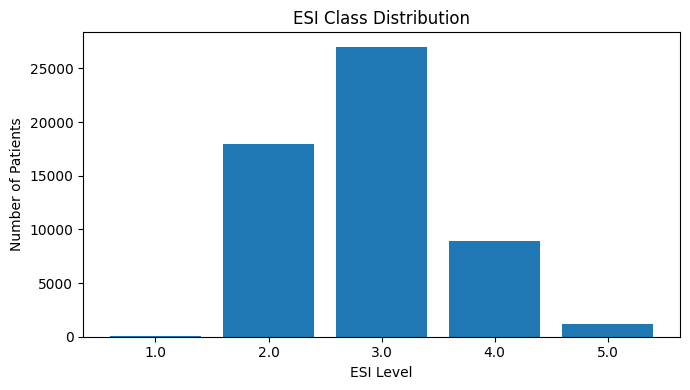

In [6]:
esi_counts = df[TARGET].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(esi_counts.index.astype(str), esi_counts.values)
plt.title("ESI Class Distribution")
plt.xlabel("ESI Level")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()


### Observation

If ESI Levels 1 and 5 are rare, overall accuracy may appear acceptable even when the model performs poorly on clinically important minority classes.


## Define Features and Remove Leakage

Only information available at triage should be used as model inputs. Post-triage outcomes such as disposition are excluded because they would cause data leakage.


In [7]:
VITALS = [
    "triage_vital_hr",
    "triage_vital_sbp",
    "triage_vital_dbp",
    "triage_vital_rr",
    "triage_vital_o2",
    "triage_vital_temp",
    "triage_glucose"
]

DEMOGRAPHICS = [
    "age", "gender", "ethnicity", "race", "lang", "religion",
    "maritalstatus", "employstatus", "insurance_status"
]

ADMIN = [
    "dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"
]

LEAKAGE = ["disposition", "previousdispo"]

excluded_columns = [TARGET] + DEMOGRAPHICS + ADMIN + LEAKAGE

FEATURES = [col for col in df.columns if col not in excluded_columns]

print("Number of model features:", len(FEATURES))
print("First 15 features:")
print(FEATURES[:15])


Number of model features: 209
First 15 features:
['Unnamed: 0', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp', 'triage_vital_rr', 'triage_vital_o2', 'triage_vital_o2_device', 'triage_vital_temp', 'triage_glucose', 'cc_abdominalcramping', 'cc_abdominaldistention', 'cc_abdominalpain', 'cc_abdominalpainpregnant', 'cc_abnormallab', 'cc_abscess']


## Prepare the Feature Matrix

The models require numeric input. Any unexpected non-numeric values are converted to missing values and then filled using the column median. This is a defensive check; the Week 5 cleaned dataset should already be numeric and complete.


In [8]:
X = df[FEATURES].copy()
y = df[TARGET].copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

missing_before = int(X.isna().sum().sum())

if missing_before > 0:
    X = X.fillna(X.median(numeric_only=True))

if y.isna().any():
    valid_rows = y.notna()
    X = X.loc[valid_rows].copy()
    y = y.loc[valid_rows].copy()

y = y.astype(int)

print("Missing feature values before defensive filling:", missing_before)
print("Missing feature values after defensive filling:", int(X.isna().sum().sum()))
print("Final feature matrix shape:", X.shape)
print("Final target shape:", y.shape)


Missing feature values before defensive filling: 0
Missing feature values after defensive filling: 0
Final feature matrix shape: (55121, 209)
Final target shape: (55121,)


## Split the Data into Training and Test Sets

An 80/20 stratified split preserves the relative proportion of ESI classes. `random_state=42` makes the split reproducible.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (44096, 209)
Test set: (11025, 209)


## Train a Stratified Random Baseline

The Dummy Classifier guesses ESI levels according to their frequency in the training data. The real models should outperform this baseline.


In [10]:
dummy = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_STATE
)

dummy.fit(X_train, y_train)
pred_dummy = dummy.predict(X_test)

print("Dummy baseline accuracy:", round(accuracy_score(y_test, pred_dummy), 4))


Dummy baseline accuracy: 0.3754


## Train Logistic Regression

Logistic Regression requires scaled features because its optimisation is affected by differences in measurement scale.


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logreg = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)

logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)

print("Logistic Regression accuracy:", round(accuracy_score(y_test, pred_logreg), 4))


Logistic Regression accuracy: 0.5629


## Train the Decision Tree

A maximum depth of 5 is used to reduce overfitting and preserve interpretability.


In [12]:
tree = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

print("Decision Tree accuracy:", round(accuracy_score(y_test, pred_tree), 4))


Decision Tree accuracy: 0.2703


## Evaluate Each Model

The classification report provides precision, recall, F1-score, and support for each ESI class.


In [13]:
def print_model_report(name, y_true, y_pred):
    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))

print_model_report("Dummy Classifier", y_test, pred_dummy)
print_model_report("Logistic Regression", y_test, pred_logreg)
print_model_report("Decision Tree", y_test, pred_tree)


Dummy Classifier
              precision    recall  f1-score   support

           1      0.000     0.000     0.000        16
           2      0.334     0.327     0.331      3585
           3      0.491     0.498     0.494      5402
           4      0.147     0.148     0.147      1779
           5      0.049     0.045     0.047       243

    accuracy                          0.375     11025
   macro avg      0.204     0.204     0.204     11025
weighted avg      0.374     0.375     0.375     11025

Logistic Regression
              precision    recall  f1-score   support

           1      0.017     0.625     0.032        16
           2      0.656     0.601     0.627      3585
           3      0.762     0.500     0.604      5402
           4      0.490     0.657     0.561      1779
           5      0.141     0.700     0.234       243

    accuracy                          0.563     11025
   macro avg      0.413     0.617     0.412     11025
weighted avg      0.669     0.563     0.

## Confusion Matrices

The most serious failure is an ESI Level 1 patient being predicted as a less urgent class.


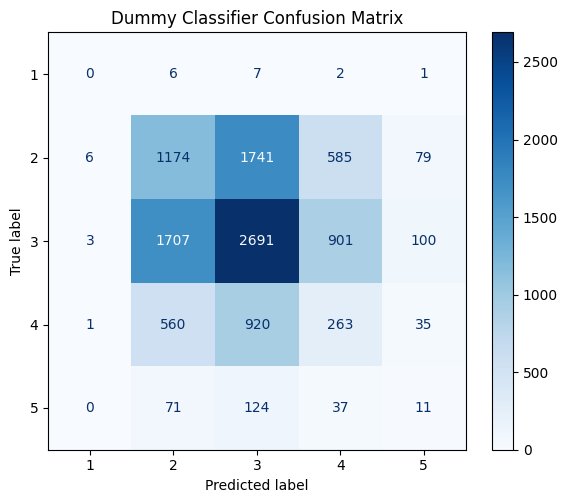

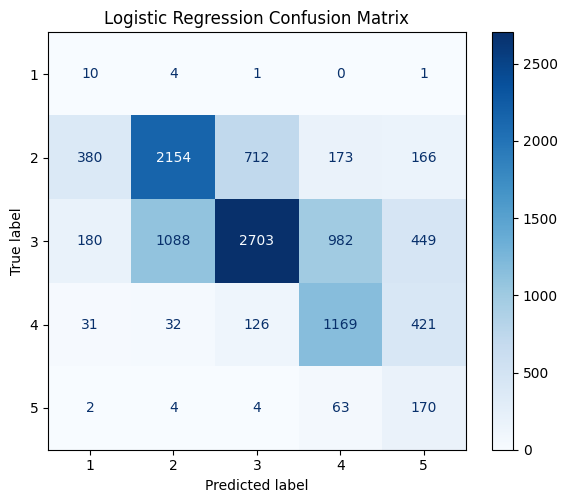

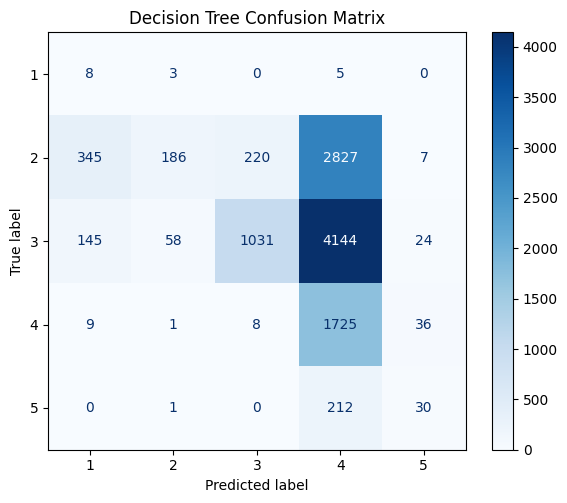

In [14]:
os.makedirs("figs", exist_ok=True)

models_and_predictions = {
    "Dummy Classifier": pred_dummy,
    "Logistic Regression": pred_logreg,
    "Decision Tree": pred_tree
}

for model_name, predictions in models_and_predictions.items():
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=sorted(y.unique()),
        cmap="Blues",
        values_format="d",
        ax=ax
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    plt.tight_layout()

    safe_name = model_name.lower().replace(" ", "_")
    plt.savefig(f"figs/{safe_name}_confusion_matrix.png", dpi=150)
    plt.show()


## Compare Overall Model Performance

Macro F1 gives equal importance to every ESI class. Weighted F1 gives more influence to common classes. A large gap between them suggests stronger performance on common classes than on rare classes.


In [15]:
def model_metrics(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1": f1_score(y_true, y_pred, average="weighted", zero_division=0)
    }

comparison = pd.DataFrame([
    model_metrics("Dummy Classifier", y_test, pred_dummy),
    model_metrics("Logistic Regression", y_test, pred_logreg),
    model_metrics("Decision Tree", y_test, pred_tree)
])

numeric_cols = comparison.columns.drop("Model")
comparison[numeric_cols] = comparison[numeric_cols].round(3)

comparison


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Dummy Classifier,0.375,0.204,0.204,0.204,0.375
1,Logistic Regression,0.563,0.413,0.617,0.412,0.596
2,Decision Tree,0.270,0.417,0.367,0.187,0.239


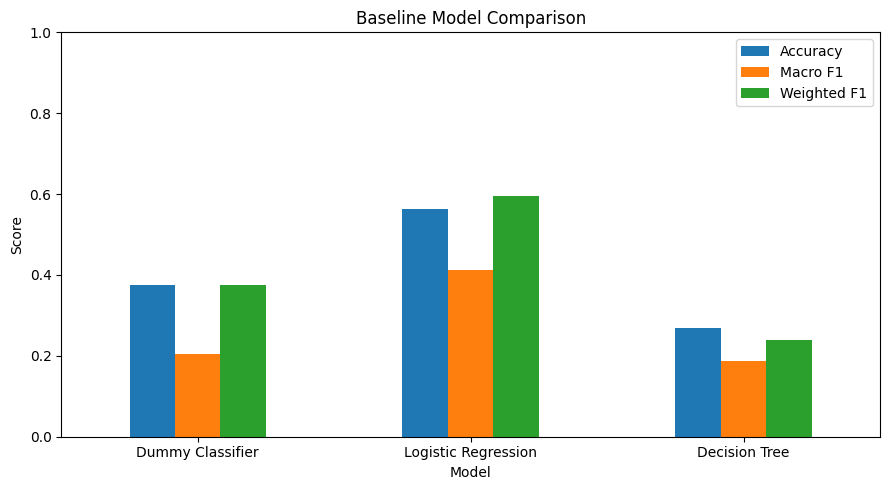

In [16]:
comparison_plot = comparison.set_index("Model")[["Accuracy", "Macro F1", "Weighted F1"]]

comparison_plot.plot(kind="bar", figsize=(9, 5))
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("figs/model_comparison.png", dpi=150)
plt.show()


##  ESI Level 1 Recall

Recall for ESI Level 1 answers: of all patients who truly required immediate life-saving intervention, what proportion did the model correctly identify as ESI 1?


In [17]:
def class_recall(y_true, y_pred, class_label=1):
    return recall_score(
        y_true,
        y_pred,
        labels=[class_label],
        average=None,
        zero_division=0
    )[0]

esi1_recall_table = pd.DataFrame({
    "Model": ["Dummy Classifier", "Logistic Regression", "Decision Tree"],
    "ESI 1 Recall": [
        class_recall(y_test, pred_dummy, 1),
        class_recall(y_test, pred_logreg, 1),
        class_recall(y_test, pred_tree, 1)
    ]
})

esi1_recall_table["ESI 1 Recall"] = esi1_recall_table["ESI 1 Recall"].round(3)
esi1_recall_table


,Model,ESI 1 Recall
0,Dummy Classifier,0.000
1,Logistic Regression,0.625
2,Decision Tree,0.500


## Primary Metric Justification

**Primary metric: Recall for ESI Level 1**

Recall for ESI Level 1 is prioritised because the most dangerous error is failing to identify a patient who requires immediate life-saving intervention. If a true ESI 1 patient is assigned a lower-priority category, treatment may be delayed and the patient's condition could rapidly worsen. By contrast, assigning a stable patient to a higher-acuity category may increase resource use, but it is generally less harmful than under-triaging a critically ill patient. Overall accuracy is not sufficient because ESI 1 patients are relatively rare, allowing a model to appear accurate while still missing the sickest patients.


## Failure-Mode Reflection

The failure mode of greatest concern is under-triage, especially when an ESI Level 1 patient is predicted as ESI 2, 3, 4, or 5. In practice, this could delay resuscitation, monitoring, or senior clinical review. The confusion matrices should therefore be examined for how often true ESI 1 cases are placed outside the ESI 1 column.


##  Save the Models and Outputs


In [18]:
os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

joblib.dump(dummy, "models/dummy_classifier.joblib")
joblib.dump(logreg, "models/logistic_regression.joblib")
joblib.dump(tree, "models/decision_tree.joblib")
joblib.dump(scaler, "models/standard_scaler.joblib")
joblib.dump(FEATURES, "models/feature_list.joblib")

comparison.to_csv("outputs/model_comparison.csv", index=False)
esi1_recall_table.to_csv("outputs/esi1_recall_comparison.csv", index=False)

print("Models and evaluation tables saved successfully.")


Models and evaluation tables saved successfully.



# Week 7 Extension: Complex Model

The Week 7 complex model is a **Random Forest Classifier**. A random forest combines many decision trees and uses their collective vote. It is more flexible than Logistic Regression, can model non-linear relationships, and provides feature importance values for interpretation.



## Clinical Feature Engineering

The following features are derived only from information available at triage. They represent clinically meaningful combinations and red flags across cardiovascular, respiratory, temperature, and metabolic systems.


In [19]:

def add_clinical_features(data):
    out = data.copy()

    # Avoid division by zero by replacing zero denominators with NaN temporarily.
    safe_sbp = out["triage_vital_sbp"].replace(0, np.nan)
    safe_rr = out["triage_vital_rr"].replace(0, np.nan)

    # Ratios and combinations
    out["shock_index"] = out["triage_vital_hr"] / safe_sbp
    out["pulse_pressure"] = (
        out["triage_vital_sbp"] - out["triage_vital_dbp"]
    )
    out["spo2_rr_ratio"] = out["triage_vital_o2"] / safe_rr

    # Non-blood-pressure red flags
    out["is_tachypnoeic"] = (out["triage_vital_rr"] > 20).astype(int)
    out["is_hypoxic"] = (out["triage_vital_o2"] < 92).astype(int)
    out["is_febrile"] = (out["triage_vital_temp"] >= 100.4).astype(int)
    out["is_hypothermic"] = (out["triage_vital_temp"] < 96.8).astype(int)
    out["is_hyperglycaemic"] = (out["triage_glucose"] > 180).astype(int)

    out["red_flag_count"] = out[
        [
            "is_tachypnoeic",
            "is_hypoxic",
            "is_febrile",
            "is_hypothermic",
            "is_hyperglycaemic"
        ]
    ].sum(axis=1)

    # Replace any infinities created by division and fill derived gaps
    # using training-set medians later.
    out = out.replace([np.inf, -np.inf], np.nan)

    return out


X_train_fe = add_clinical_features(X_train)
X_test_fe = add_clinical_features(X_test)

# Use only training-set medians to avoid test-set information leakage.
feature_medians = X_train_fe.median(numeric_only=True)
X_train_fe = X_train_fe.fillna(feature_medians)
X_test_fe = X_test_fe.fillna(feature_medians)

print("Original number of features:", X_train.shape[1])
print("Number after feature engineering:", X_train_fe.shape[1])
X_train_fe.head()


Original number of features: 209
Number after feature engineering: 218


,Unnamed: 0,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,cc_abdominalpain,cc_abdominalpainpregnant,cc_abnormallab,cc_abscess,cc_addictionproblem,cc_agitation,cc_alcoholintoxication,cc_alcoholproblem,cc_allergicreaction,cc_alteredmentalstatus,cc_animalbite,cc_ankleinjury,cc_anklepain,cc_anxiety,cc_arminjury,cc_armpain,cc_armswelling,cc_assaultvictim,cc_asthma,cc_backpain,cc_bleeding/bruising,cc_blurredvision,cc_bodyfluidexposure,cc_breastpain,cc_breathingdifficulty,cc_breathingproblem,cc_burn,cc_cardiacarrest,cc_cellulitis,...,cc_skinproblem,cc_sorethroat,cc_stdcheck,cc_strokealert,cc_suicidal,cc_suture/stapleremoval,cc_swallowedforeignbody,cc_syncope,cc_tachycardia,cc_testiclepain,cc_thumbinjury,cc_tickremoval,cc_toeinjury,cc_toepain,cc_trauma,cc_unresponsive,cc_uri,cc_urinaryfrequency,cc_urinaryretention,cc_urinarytractinfection,cc_vaginalbleeding,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain,shock_index,pulse_pressure,spo2_rr_ratio,is_tachypnoeic,is_hypoxic,is_febrile,is_hypothermic,is_hyperglycaemic,red_flag_count
35369,258794,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.866667,49.0,4.454545,1,0,0,0,0,1
52043,397606,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.678261,39.0,5.333333,0,0,0,0,0,0
13610,100469,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.806723,41.0,5.222222,0,0,0,0,0,0
54796,428649,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.695312,35.0,6.125000,0,0,0,0,0,0
11096,81548,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.787611,35.0,5.444444,0,0,0,0,0,0



## Re-time the Week 6 Logistic Regression Baseline

The baseline is retrained on the same Week 6 split so that training and inference times are measured consistently. Logistic Regression uses the original Week 6 feature set.


In [20]:

baseline_scaler = StandardScaler()

baseline_train_start = time.perf_counter()
X_train_scaled_timed = baseline_scaler.fit_transform(X_train)
X_test_scaled_timed = baseline_scaler.transform(X_test)

baseline_timed = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    class_weight="balanced"
)
baseline_timed.fit(X_train_scaled_timed, y_train)
baseline_training_time = time.perf_counter() - baseline_train_start

baseline_inference_start = time.perf_counter()
pred_baseline_timed = baseline_timed.predict(X_test_scaled_timed)
baseline_total_inference_time = time.perf_counter() - baseline_inference_start
baseline_ms_per_prediction = (
    baseline_total_inference_time / len(X_test_scaled_timed)
) * 1000

print(f"Logistic Regression training time: {baseline_training_time:.4f} seconds")
print(f"Logistic Regression inference time: {baseline_ms_per_prediction:.6f} ms per prediction")


Logistic Regression training time: 15.6166 seconds
Logistic Regression inference time: 0.001426 ms per prediction



## Train an Initial Random Forest

The untuned model provides an initial reference before optimisation. `class_weight="balanced"` increases the influence of rare ESI classes during training.


In [21]:

initial_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

initial_rf_start = time.perf_counter()
initial_rf.fit(X_train_fe, y_train)
initial_rf_training_time = time.perf_counter() - initial_rf_start

initial_rf_inference_start = time.perf_counter()
pred_initial_rf = initial_rf.predict(X_test_fe)
initial_rf_total_inference_time = time.perf_counter() - initial_rf_inference_start
initial_rf_ms_per_prediction = (
    initial_rf_total_inference_time / len(X_test_fe)
) * 1000

print("Initial Random Forest macro F1:",
      round(f1_score(y_test, pred_initial_rf, average="macro", zero_division=0), 4))
print(f"Training time: {initial_rf_training_time:.4f} seconds")
print(f"Inference time: {initial_rf_ms_per_prediction:.6f} ms per prediction")


Initial Random Forest macro F1: 0.3826
Training time: 42.9743 seconds
Inference time: 0.089879 ms per prediction



## Tune the Random Forest with Cross-Validation

`RandomizedSearchCV` tests a limited set of parameter combinations using three-fold cross-validation. Macro F1 is used because it gives equal importance to all five ESI classes.


In [22]:

rf_search_space = {
    "n_estimators": [150, 250, 350],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_for_tuning = RandomForestClassifier(
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search = RandomizedSearchCV(
    estimator=rf_for_tuning,
    param_distributions=rf_search_space,
    n_iter=8,
    scoring="f1_macro",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    return_train_score=False
)

tuning_start = time.perf_counter()
rf_search.fit(X_train_fe, y_train)
rf_tuning_time = time.perf_counter() - tuning_start

best_rf = rf_search.best_estimator_

print("Best parameters:")
print(rf_search.best_params_)
print("Best cross-validation macro F1:", round(rf_search.best_score_, 4))
print(f"Total tuning time: {rf_tuning_time:.2f} seconds")


Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters:
{'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}
Best cross-validation macro F1: 0.4699
Total tuning time: 328.95 seconds



## Evaluate the Tuned Random Forest


In [23]:

rf_inference_start = time.perf_counter()
pred_rf = best_rf.predict(X_test_fe)
rf_total_inference_time = time.perf_counter() - rf_inference_start
rf_ms_per_prediction = (rf_total_inference_time / len(X_test_fe)) * 1000

print_model_report("Tuned Random Forest", y_test, pred_rf)
print(f"Inference time: {rf_ms_per_prediction:.6f} ms per prediction")


Tuned Random Forest
              precision    recall  f1-score   support

           1      0.333     0.312     0.323        16
           2      0.645     0.684     0.664      3585
           3      0.728     0.522     0.608      5402
           4      0.448     0.711     0.550      1779
           5      0.232     0.490     0.315       243

    accuracy                          0.604     11025
   macro avg      0.477     0.544     0.492     11025
weighted avg      0.644     0.604     0.610     11025

Inference time: 0.039714 ms per prediction



## Six-Axis Benchmark

Macro precision, macro recall, and macro F1 treat each ESI class equally. Training time for the Random Forest includes model fitting after tuning; the separate tuning duration is also reported because it represents an additional development cost.


In [24]:

def timed_benchmark_row(
    name,
    y_true,
    y_pred,
    training_seconds,
    inference_ms_per_prediction,
    interpretability
):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro Recall": recall_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Macro F1": f1_score(
            y_true, y_pred, average="macro", zero_division=0
        ),
        "Training Time (s)": training_seconds,
        "Inference Time (ms/prediction)": inference_ms_per_prediction,
        "Interpretability": interpretability
    }


# Measure the final best estimator's fit time separately from the tuning search.
final_rf_train_start = time.perf_counter()
best_rf.fit(X_train_fe, y_train)
final_rf_training_time = time.perf_counter() - final_rf_train_start

rf_inference_start = time.perf_counter()
pred_rf = best_rf.predict(X_test_fe)
rf_total_inference_time = time.perf_counter() - rf_inference_start
rf_ms_per_prediction = (rf_total_inference_time / len(X_test_fe)) * 1000

week7_benchmark = pd.DataFrame([
    timed_benchmark_row(
        "Logistic Regression",
        y_test,
        pred_baseline_timed,
        baseline_training_time,
        baseline_ms_per_prediction,
        "High: coefficients can be explained, although 209 features make a single prediction lengthy."
    ),
    timed_benchmark_row(
        "Tuned Random Forest",
        y_test,
        pred_rf,
        final_rf_training_time,
        rf_ms_per_prediction,
        "Moderate: global feature importance is available, but one prediction is less transparent than Logistic Regression."
    )
])

display_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Training Time (s)",
    "Inference Time (ms/prediction)"
]
week7_benchmark[display_columns] = week7_benchmark[display_columns].round(6)

week7_benchmark


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1,Training Time (s),Inference Time (ms/prediction),Interpretability
0,Logistic Regression,0.562902,0.413148,0.616581,0.411902,15.616576,0.001426,"High: coefficients can be explained, although ..."
1,Tuned Random Forest,0.604172,0.477303,0.543798,0.491820,22.178765,0.074344,Moderate: global feature importance is availab...



## ESI Level 1 Recall

Although the assignment asks for six overall benchmark axes, ESI Level 1 recall is retained as a clinically important safety measure because it shows how often the model correctly identifies the most urgent patients.


In [25]:

week7_esi1_recall = pd.DataFrame({
    "Model": ["Logistic Regression", "Tuned Random Forest"],
    "ESI 1 Recall": [
        class_recall(y_test, pred_baseline_timed, 1),
        class_recall(y_test, pred_rf, 1)
    ]
})

week7_esi1_recall["ESI 1 Recall"] = (
    week7_esi1_recall["ESI 1 Recall"].round(3)
)

week7_esi1_recall


,Model,ESI 1 Recall
0,Logistic Regression,0.625
1,Tuned Random Forest,0.312



## Random Forest Feature Importance

Feature importance indicates which variables contributed most strongly across the forest. It provides global interpretability, but it does not by itself explain the reason for every individual prediction.


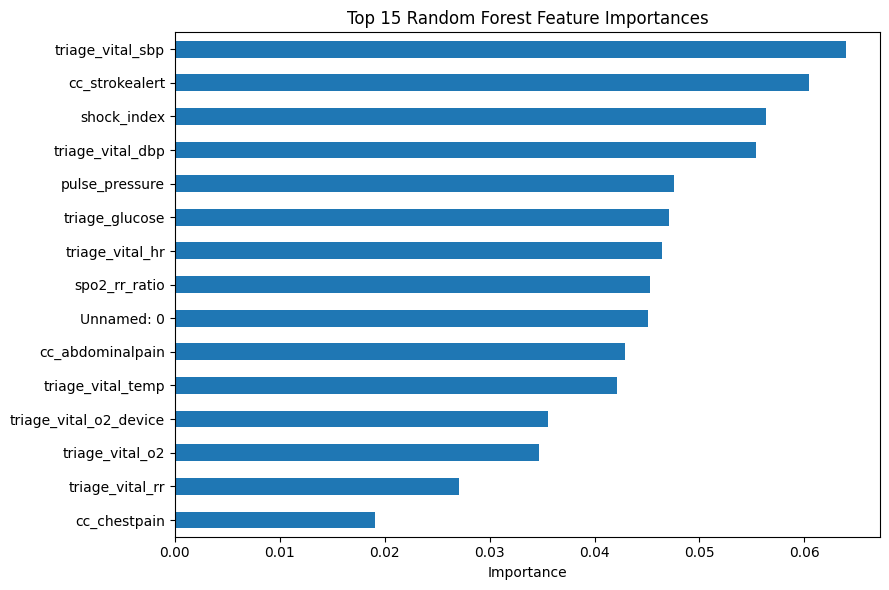

,Importance
triage_vital_sbp,0.06400
cc_strokealert,0.06041
shock_index,0.05635
triage_vital_dbp,0.05540
pulse_pressure,0.04761
triage_glucose,0.04705
triage_vital_hr,0.04642
spo2_rr_ratio,0.04526
Unnamed: 0,0.04508
cc_abdominalpain,0.04288


In [26]:

feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=X_train_fe.columns
).sort_values(ascending=False)

top_15_importance = feature_importance.head(15).sort_values()

plt.figure(figsize=(9, 6))
top_15_importance.plot(kind="barh")
plt.title("Top 15 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("figs/week7_random_forest_feature_importance.png", dpi=150)
plt.show()

display(feature_importance.head(15).to_frame("Importance").round(5))



## Initial Interim Interpretation

The final recommendation should depend on the executed benchmark results rather than model complexity alone. The Random Forest should only be preferred if its improvement in clinically relevant performance is meaningful enough to justify its slower training, reduced transparency, and additional governance burden. Inference time is expected to remain small relative to the several minutes available for triage, but this must be confirmed using the measured results above.



## Save Week 7 Interim Outputs


In [27]:

os.makedirs("models", exist_ok=True)
os.makedirs("outputs", exist_ok=True)
os.makedirs("docs", exist_ok=True)

joblib.dump(best_rf, "models/week7_tuned_random_forest.joblib")
joblib.dump(feature_medians, "models/week7_feature_medians.joblib")
joblib.dump(list(X_train_fe.columns), "models/week7_feature_list.joblib")

week7_benchmark.to_csv(
    "outputs/week7_interim_benchmark.csv",
    index=False
)
week7_esi1_recall.to_csv(
    "outputs/week7_esi1_recall.csv",
    index=False
)

# Create the required draft benchmark table in Markdown.
markdown_table = week7_benchmark.to_markdown(index=False)

with open("docs/week-7-benchmark-table.md", "w", encoding="utf-8") as file:
    file.write("# Week 7 Draft Benchmark Table\n\n")
    file.write(
        "This table compares the Week 6 Logistic Regression baseline "
        "with the tuned Week 7 Random Forest using the same 80/20 "
        "stratified train/test split (`random_state=42`).\n\n"
    )
    file.write(markdown_table)
    file.write("\n\n")
    file.write(
        f"Random Forest tuning time: {rf_tuning_time:.2f} seconds.\n"
    )
    file.write(
        "\n**Note:** Values are initial interim results and will be "
        "reviewed in the final cost-benefit memo.\n"
    )

print("Week 7 model and interim outputs saved.")
print("Draft table: docs/week-7-benchmark-table.md")


Week 7 model and interim outputs saved.
Draft table: docs/week-7-benchmark-table.md
